# Interpretabilidad: SHAP, LIME y las funciones de forma de la EBM

La guía (§5.3) pide explicar el mejor modelo de cada tarea con SHAP —una vista global y al menos dos
explicaciones individuales, una bien predicha y otra con error alto—, aplicar LIME a XGBoost y
discutir en qué se diferencian. El mejor modelo de las dos tareas según la validación anidada es
**XGBoost**, de modo que es el que se explica aquí; el modelo nuevo, la EBM, sirve de contraste
porque es interpretable por construcción.

**SHAP** (Lundberg y Lee, 2017) reparte la predicción de cada cliente entre las variables con los
valores de Shapley de la teoría de juegos cooperativos: la contribución de una variable es su aporte
marginal promedio sobre todas las coaliciones posibles de variables. Es el único reparto que cumple a
la vez cuatro propiedades: **eficiencia** (las contribuciones suman la diferencia entre la predicción y
su media), **simetría** (dos variables que aportan lo mismo en toda coalición reciben lo mismo),
**jugador nulo** (una variable que no cambia ninguna predicción recibe cero) y **aditividad** (en un
ensamble, la contribución es la suma de las de sus partes). Para árboles, TreeSHAP los calcula de
forma **exacta** y en tiempo polinómico, y las contribuciones suman exactamente la diferencia entre
la predicción del cliente y la predicción media (en clasificación, en la escala del logit).
**LIME** (Ribeiro, Singh y Guestrin, 2016) ajusta, alrededor de cada cliente, un modelo lineal a
las predicciones del modelo sobre perturbaciones de ese cliente: es una aproximación local, no una
descomposición exacta.

In [1]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import Markdown, display
from lime.lime_tabular import LimeTabularExplainer

from src import analisis, datos, graficos
from src.formato import dec, ent, enumerar, pct
from src.preprocesamiento import columnas_por_tipo, nombres_variables

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

tabla = analisis.cargar_tabla()
p = datos.preparar_todo()                                 # etiqueta del percentil 75
c = p['conjuntos']
X_te = c.X_test.sort_index()
y_te, y_te_c = p['y_test'].loc[X_te.index], c.y_test_cont.loc[X_te.index]
mejor = {t: analisis.mejores_por_modelo(tabla, t).iloc[0] for t in ('clasificacion', 'regresion')}
modelo = {t: joblib.load(f['ruta_modelo']) for t, f in mejor.items()}
for t, f in mejor.items():
    print(f'{t}: {f["modelo"]} · {f["balanceo"]} · {f["optimizador"]} · métrica externa {f["metrica"]:.4f}')


def matrices(pipeline, X):
    """Matriz transformada (lo que ve el modelo) y matriz para mostrar en unidades originales."""
    pre = pipeline.named_steps['preprocesado']
    nombres = nombres_variables(pre)
    Z = pre.transform(X)
    numericas, _ = columnas_por_tipo(X)
    mostrar = Z.copy()
    mostrar[:, :len(numericas)] = X[numericas].astype(float).to_numpy()
    return Z, mostrar, nombres

clasificacion: xgboost · class_weight · genetica · métrica externa 0.8332
regresion: xgboost · ninguno · bayesiana · métrica externa 0.0590


## Clasificación: vista global

El gráfico de enjambre ordena las variables por la media del valor absoluto de su contribución.
Cada punto es un cliente de prueba; su posición horizontal es la contribución de la variable a su
logit de riesgo alto y su color, el valor de la variable (rojo alto, azul bajo).

las contribuciones suman el margen del modelo en todos los clientes: True


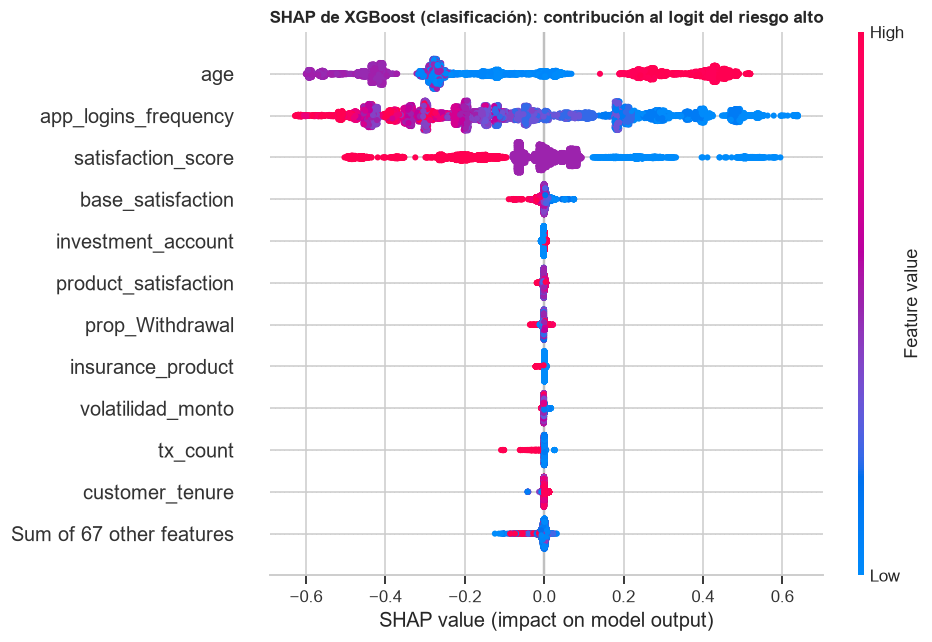

In [2]:
Z_clf, mostrar_clf, nombres = matrices(modelo['clasificacion'], X_te)
xgb_clf = modelo['clasificacion'].named_steps['modelo']
explicador = shap.TreeExplainer(xgb_clf)
sv = explicador(Z_clf)
sv = shap.Explanation(sv.values, base_values=sv.base_values, data=mostrar_clf, feature_names=nombres)
margen = xgb_clf.predict(Z_clf, output_margin=True)
print('las contribuciones suman el margen del modelo en todos los clientes:',
      bool(np.allclose(sv.values.sum(axis=1) + sv.base_values, margen, atol=1e-4)))
shap.plots.beeswarm(sv, max_display=12, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title('SHAP de XGBoost (clasificación): contribución al logit del riesgo alto', fontsize=11)
plt.tight_layout()
plt.show()

In [3]:
importancia = pd.Series(np.abs(sv.values).mean(axis=0), index=nombres).sort_values(ascending=False)
cuota = importancia / importancia.sum()
top4 = list(cuota.index[:4])
display(cuota.head(10).to_frame('cuota del |SHAP| medio'))
display(Markdown(f"""
Cuatro variables concentran el {pct(cuota.iloc[:4].sum(), 0)} de la contribución total:
{enumerar(f'`{v}` ({pct(cuota[v], 0)})' for v in top4)}. Es el mismo grupo que señalaron el análisis de
variables y la EBM, aunque llegan a él por caminos distintos. Más inicios de sesión en la aplicación
y más satisfacción reducen el riesgo; la edad tiene un efecto por tramos que la EBM muestra con más
detalle al final de esta página.
"""))

,cuota del |SHAP| medio
age,0.4320
app_logins_frequency,0.3615
satisfaction_score,0.1617
base_satisfaction,0.0105
investment_account,0.0025
product_satisfaction,0.0025
prop_Withdrawal,0.0024
insurance_product,0.0020
volatilidad_monto,0.0020
tx_count,0.0019



Cuatro variables concentran el 97 % de la contribución total:
`age` (43 %), `app_logins_frequency` (36 %), `satisfaction_score` (16 %) y `base_satisfaction` (1 %). Es el mismo grupo que señalaron el análisis de
variables y la EBM, aunque llegan a él por caminos distintos. Más inicios de sesión en la aplicación
y más satisfacción reducen el riesgo; la edad tiene un efecto por tramos que la EBM muestra con más
detalle al final de esta página.


## Clasificación: dos clientes

Se explican dos clientes de prueba que son de riesgo alto: el que el modelo identifica con más
seguridad (bien predicho) y el que el modelo considera de menor riesgo (el error más grave: un
cliente que se va y que el modelo deja fuera de cualquier campaña).

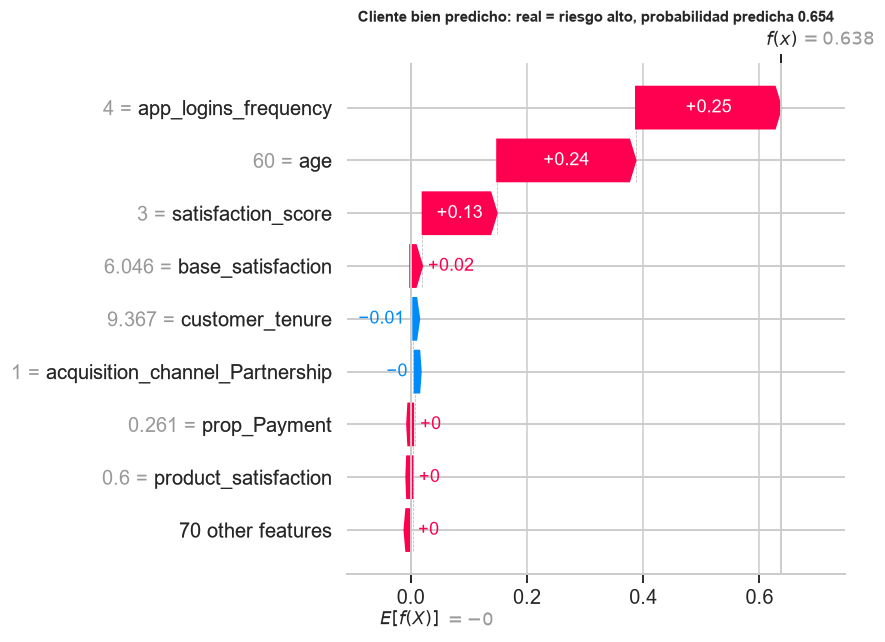

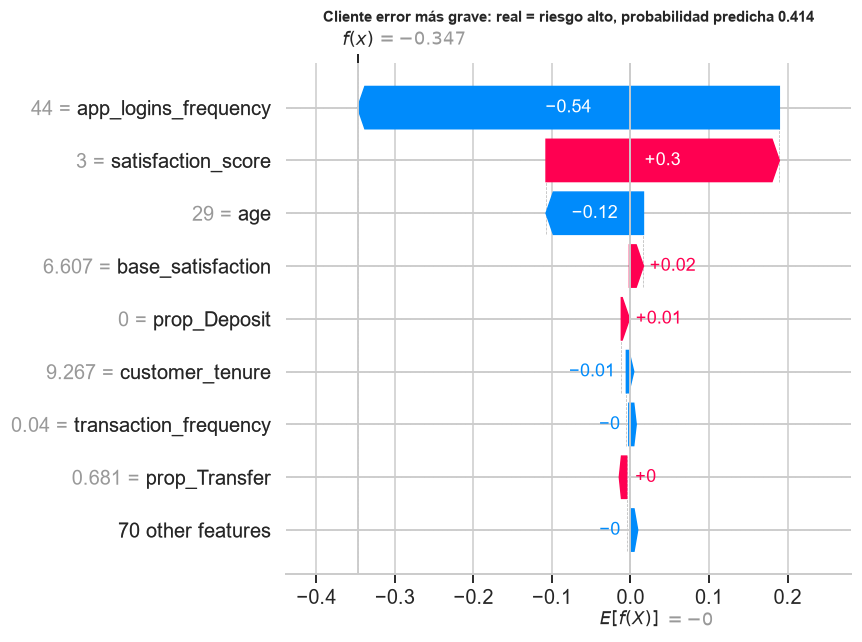

In [4]:
proba = modelo['clasificacion'].predict_proba(X_te)[:, 1]
positivos = np.flatnonzero(y_te.to_numpy() == 1)
bien = positivos[np.argmax(proba[positivos])]
mal = positivos[np.argmin(proba[positivos])]
for idx, titulo in ((bien, 'bien predicho'), (mal, 'error más grave')):
    plt.figure(figsize=(8.5, 4.6))
    shap.plots.waterfall(sv[idx], max_display=9, show=False)
    plt.title(f'Cliente {titulo}: real = riesgo alto, probabilidad predicha {proba[idx]:.3f}', fontsize=10)
    plt.tight_layout()
    plt.show()

## Regresión

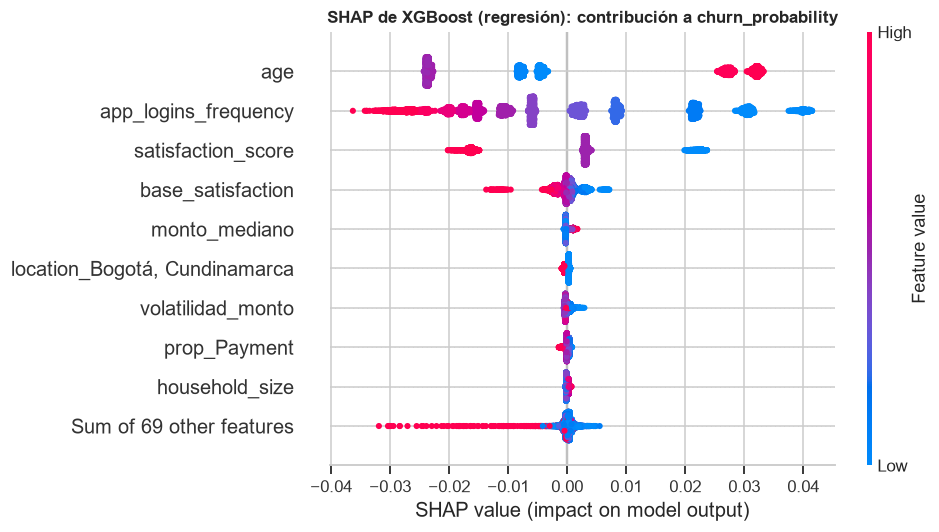

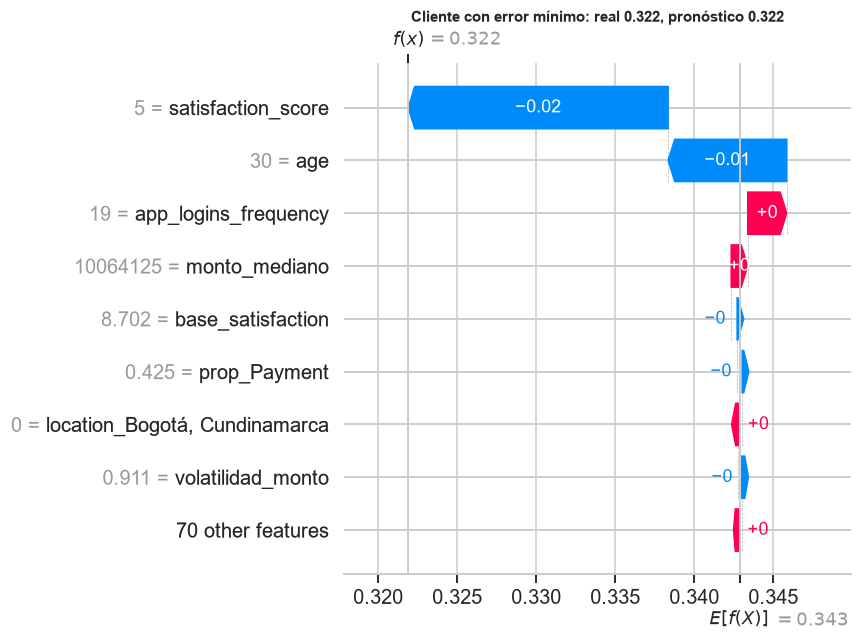

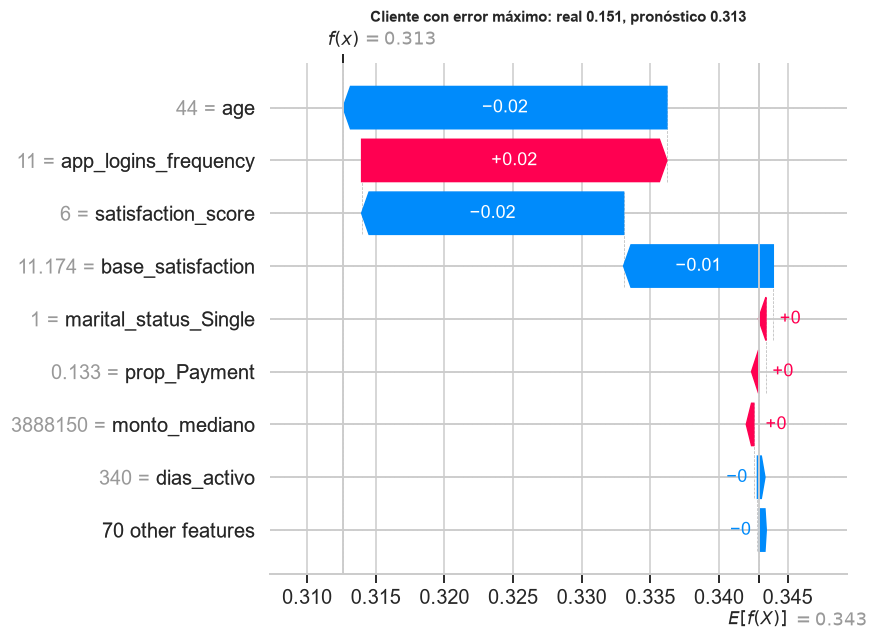

In [5]:
Z_reg, mostrar_reg, nombres_r = matrices(modelo['regresion'], X_te)
xgb_reg = modelo['regresion'].named_steps['modelo']
sv_r = shap.TreeExplainer(xgb_reg)(Z_reg)
sv_r = shap.Explanation(sv_r.values, base_values=sv_r.base_values, data=mostrar_reg, feature_names=nombres_r)
pron = modelo['regresion'].predict(X_te)
error = np.abs(y_te_c.to_numpy() - pron)
bien_r, mal_r = int(np.argmin(error)), int(np.argmax(error))
shap.plots.beeswarm(sv_r, max_display=10, show=False)
plt.gcf().set_size_inches(9, 5)
plt.title('SHAP de XGBoost (regresión): contribución a churn_probability', fontsize=11)
plt.tight_layout()
plt.show()
for idx, titulo in ((bien_r, 'error mínimo'), (mal_r, 'error máximo')):
    plt.figure(figsize=(8.5, 4.6))
    shap.plots.waterfall(sv_r[idx], max_display=9, show=False)
    plt.title(f'Cliente con {titulo}: real {y_te_c.iloc[idx]:.3f}, pronóstico {pron[idx]:.3f}', fontsize=10)
    plt.tight_layout()
    plt.show()

In [6]:
cuota_r = pd.Series(np.abs(sv_r.values).mean(axis=0), index=nombres_r)
cuota_r = (cuota_r / cuota_r.sum()).sort_values(ascending=False)
display(Markdown(f"""
En regresión el orden es parecido: {enumerar(f'`{v}`' for v in cuota_r.index[:4])} reúnen el
{pct(cuota_r.iloc[:4].sum(), 0)} de la contribución. El cliente con el error más grande tiene un valor real de
{dec(y_te_c.iloc[mal_r], 3)} y el modelo pronostica {dec(pron[mal_r], 3)}: sus variables observables lo parecen a
los clientes de riesgo medio, y la diferencia la explica `active_products`, que el modelo no puede
ver. Ese es el límite del techo de información: los errores grandes no son fallos del modelo sino
la parte del objetivo que depende de una variable excluida.
"""))


En regresión el orden es parecido: `age`, `app_logins_frequency`, `satisfaction_score` y `base_satisfaction` reúnen el
93 % de la contribución. El cliente con el error más grande tiene un valor real de
0,151 y el modelo pronostica 0,313: sus variables observables lo parecen a
los clientes de riesgo medio, y la diferencia la explica `active_products`, que el modelo no puede
ver. Ese es el límite del techo de información: los errores grandes no son fallos del modelo sino
la parte del objetivo que depende de una variable excluida.


## LIME sobre XGBoost y comparación con SHAP

LIME explica a los mismos dos clientes de clasificación. Como su explicación depende de
perturbaciones aleatorias, se repite con varias semillas para medir su estabilidad.

In [7]:
rng = np.random.default_rng(42)
muestra = rng.choice(len(c.X_train), 5000, replace=False)
Z_tr = modelo['clasificacion'].named_steps['preprocesado'].transform(c.X_train.iloc[muestra])
lime_exp = LimeTabularExplainer(Z_tr, feature_names=nombres, class_names=['bajo', 'alto'],
                                mode='classification', discretize_continuous=True, random_state=42)


def explicar_lime(idx, semilla, n=8):
    e = LimeTabularExplainer(Z_tr, feature_names=nombres, class_names=['bajo', 'alto'], mode='classification',
                             discretize_continuous=True, random_state=semilla)
    return e.explain_instance(Z_clf[idx], xgb_clf.predict_proba, num_features=n, num_samples=5000)


filas = []
for idx, nombre_caso in ((bien, 'bien predicho'), (mal, 'error más grave')):
    exp = explicar_lime(idx, 42)
    top_shap = pd.Series(np.abs(sv.values[idx]), index=nombres).sort_values(ascending=False).index[:5]
    top_lime = [nombres[j] for j, _ in exp.as_map()[1][:5]]
    tops = [set(nombres[j] for j, _ in explicar_lime(idx, s).as_map()[1][:5]) for s in range(5)]
    estabilidad = np.mean([len(a & b) / 5 for i, a in enumerate(tops) for b in tops[i + 1:]])
    filas.append({'cliente': nombre_caso, '5 primeras según SHAP': ', '.join(top_shap),
                  '5 primeras según LIME': ', '.join(top_lime),
                  'coincidencias SHAP–LIME (de 5)': len(set(top_shap) & set(top_lime)),
                  'estabilidad de LIME entre 5 semillas': estabilidad,
                  'R² del modelo local de LIME': exp.score})
comparacion_lime = pd.DataFrame(filas).set_index('cliente')
comparacion_lime

,5 primeras según SHAP,5 primeras según LIME,coincidencias SHAP–LIME (de 5),estabilidad de LIME entre 5 semillas,R² del modelo local de LIME
cliente,,,,,
bien predicho,"app_logins_frequency, age, satisfaction_score,...","satisfaction_score, age, app_logins_frequency,...",3,0.6400,0.4363
error más grave,"app_logins_frequency, satisfaction_score, age,...","satisfaction_score, app_logins_frequency, loca...",2,0.5200,0.4067


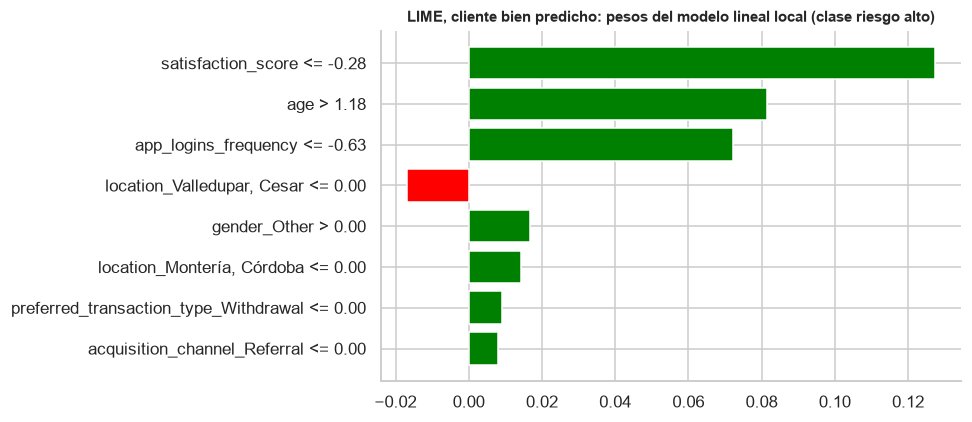

In [8]:
fig = explicar_lime(bien, 42).as_pyplot_figure()
fig.set_size_inches(9, 4)
plt.title('LIME, cliente bien predicho: pesos del modelo lineal local (clase riesgo alto)', fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
cl = comparacion_lime
display(Markdown(f"""
**LIME frente a SHAP.** Para el cliente bien predicho, {cl.iloc[0]['coincidencias SHAP–LIME (de 5)']} de las 5 variables
más importantes coinciden entre los dos métodos, y {cl.iloc[1]['coincidencias SHAP–LIME (de 5)']} para el cliente mal
predicho. Las diferencias se deben a lo que cada método mide:

- SHAP descompone *exactamente* la predicción del modelo (las contribuciones suman el logit del
  cliente) y, para árboles, sin muestreo: el resultado es único y reproducible.
- LIME ajusta un modelo lineal sobre perturbaciones alrededor del cliente, con las variables
  continuas discretizadas en cuartiles: sus pesos describen cómo cambia la predicción al mover cada
  variable de cuartil, y dependen del muestreo. Con 5.000 perturbaciones, las 5 variables principales
  coinciden en promedio en un {pct(cl['estabilidad de LIME entre 5 semillas'].mean(), 0)} entre semillas distintas, y el
  modelo lineal local explica un R² de {dec(cl['R² del modelo local de LIME'].min(), 2)} a {dec(cl['R² del modelo local de LIME'].max(), 2)} de las
  predicciones perturbadas: la aproximación es local y parcial.
- LIME trata las indicadoras de las variables categóricas como variables independientes y puede
  perturbarlas a combinaciones imposibles; SHAP, con TreeExplainer, solo recorre caminos que existen
  en los árboles.

En la práctica, SHAP sirve para auditar el modelo y para reportar por qué se marca a un cliente;
LIME, para una explicación rápida de un caso con un modelo de caja negra cualquiera, sabiendo que es
una aproximación.
"""))


**LIME frente a SHAP.** Para el cliente bien predicho, 3 de las 5 variables
más importantes coinciden entre los dos métodos, y 2 para el cliente mal
predicho. Las diferencias se deben a lo que cada método mide:

- SHAP descompone *exactamente* la predicción del modelo (las contribuciones suman el logit del
  cliente) y, para árboles, sin muestreo: el resultado es único y reproducible.
- LIME ajusta un modelo lineal sobre perturbaciones alrededor del cliente, con las variables
  continuas discretizadas en cuartiles: sus pesos describen cómo cambia la predicción al mover cada
  variable de cuartil, y dependen del muestreo. Con 5.000 perturbaciones, las 5 variables principales
  coinciden en promedio en un 58 % entre semillas distintas, y el
  modelo lineal local explica un R² de 0,41 a 0,44 de las
  predicciones perturbadas: la aproximación es local y parcial.
- LIME trata las indicadoras de las variables categóricas como variables independientes y puede
  perturbarlas a combinaciones imposibles; SHAP, con TreeExplainer, solo recorre caminos que existen
  en los árboles.

En la práctica, SHAP sirve para auditar el modelo y para reportar por qué se marca a un cliente;
LIME, para una explicación rápida de un caso con un modelo de caja negra cualquiera, sabiendo que es
una aproximación.


## La EBM como contraste: explicaciones sin modelo auxiliar

La EBM no necesita un explicador: su predicción *es* la suma de sus funciones de forma. Si SHAP
describe bien a XGBoost, la dependencia de los valores SHAP de una variable con su valor debería
parecerse a la función de forma de la EBM para esa variable.

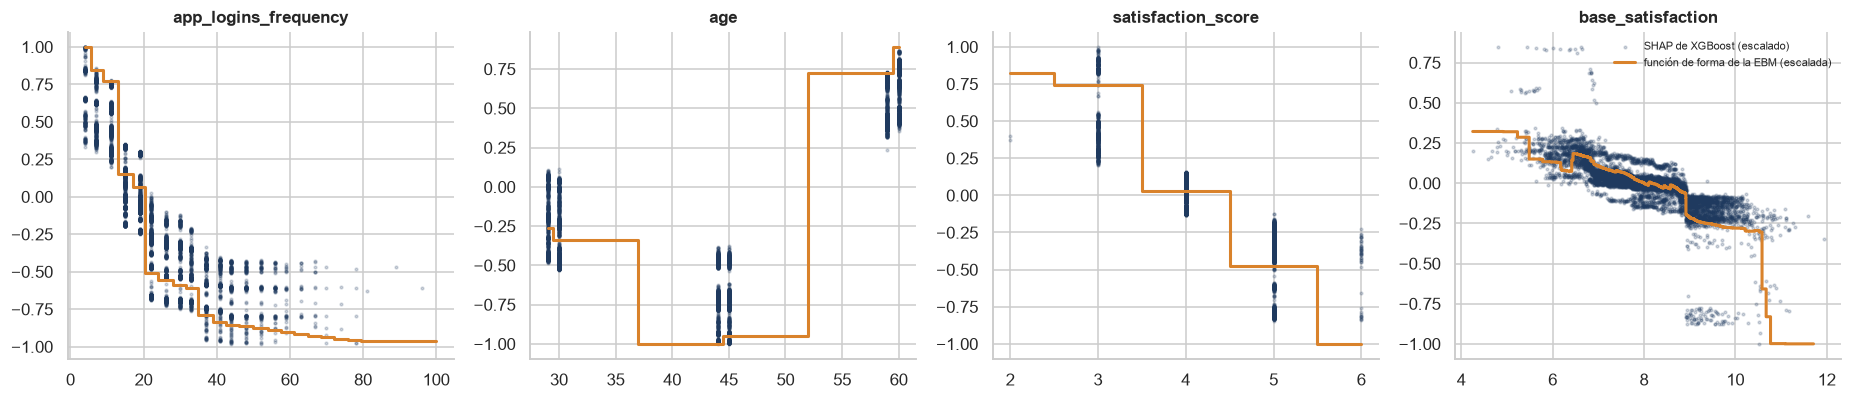


Las curvas se muestran escaladas a su máximo porque lo que interesa comparar es la forma, no la
magnitud: XGBoost se explica en la escala de su propio logit y la EBM usada es la mejor EBM de las corridas, con la misma etiqueta del percentil 75. Coinciden en la dirección y en los
tramos donde el efecto cambia: SHAP sobre XGBoost recupera la misma estructura que la EBM ofrece
directamente. Para este problema, la EBM da la explicación global sin coste adicional y con la misma
capacidad predictiva, y SHAP queda como herramienta para explicar casos individuales de modelos de
caja negra.


In [10]:
ebm = tabla[(tabla['modelo'] == 'ebm') & (tabla['tarea'] == 'clasificacion') & (tabla['estado'] == 'ok')]
if ebm.empty:
    from pathlib import Path as _P
    ruta_ebm = RAIZ / 'resultados' / 'comparacion_entrega2' / 'modelos' / 'clasificacion__ebm.joblib'
    origen = 'la EBM con la etiqueta de la mediana, la de la comparación con la Entrega 2'
else:
    ruta_ebm = analisis.mejores_por_modelo(tabla, 'clasificacion').set_index('modelo').loc['ebm', 'ruta_modelo']
    origen = 'la mejor EBM de las corridas, con la misma etiqueta del percentil 75'
ebm_modelo = joblib.load(ruta_ebm)
variables = ['app_logins_frequency', 'age', 'satisfaction_score', 'base_satisfaction']
fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, v in zip(ax, variables):
    j = nombres.index(v)
    a.scatter(mostrar_clf[:, j], sv.values[:, j] / np.abs(sv.values[:, j]).max(), s=3, alpha=0.2,
              color=graficos.AZUL, label='SHAP de XGBoost (escalado)')
    f = analisis.forma_ebm(ebm_modelo, v)
    x = np.r_[f['desde'].iloc[0], f['hasta']]
    escala = np.abs(f['efecto']).max()
    a.step(x, np.r_[f['efecto'], f['efecto'].iloc[-1]] / escala, where='post', color='#d9822b', lw=2,
           label='función de forma de la EBM (escalada)')
    a.set_title(v)
ax[-1].legend(frameon=False, fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()
display(Markdown(f"""
Las curvas se muestran escaladas a su máximo porque lo que interesa comparar es la forma, no la
magnitud: XGBoost se explica en la escala de su propio logit y la EBM usada es {origen}. Coinciden en la dirección y en los
tramos donde el efecto cambia: SHAP sobre XGBoost recupera la misma estructura que la EBM ofrece
directamente. Para este problema, la EBM da la explicación global sin coste adicional y con la misma
capacidad predictiva, y SHAP queda como herramienta para explicar casos individuales de modelos de
caja negra.
"""))